<a href="https://colab.research.google.com/github/prab369/Image_classification/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: prab369
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:05<00:00, 134MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os


device= "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:",device)


Device available: cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
   for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)
data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path","labels"])
print(data_df["labels"].unique())
data_df.head()


['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [4]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)
val = test.sample(frac = 0.5)
test= test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [5]:
from inspect import Traceback
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe, transform= None):
    self.dataframe= dataframe
    self.transform= transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)
  def __len__(self):
    return self.dataframe.shape[0]
  def __getitem__(self,idx):
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)


In [8]:
train_dataset.__getitem__(2)

(tensor([[[0.2706, 0.2706, 0.2706,  ..., 0.6353, 0.6549, 0.6824],
          [0.3020, 0.3020, 0.3020,  ..., 0.6000, 0.6157, 0.6353],
          [0.3412, 0.3412, 0.3412,  ..., 0.5725, 0.5765, 0.5843],
          ...,
          [0.3216, 0.1843, 0.0667,  ..., 0.2902, 0.4392, 0.6235],
          [0.1569, 0.0706, 0.0157,  ..., 0.3059, 0.4824, 0.6510],
          [0.0667, 0.0235, 0.0000,  ..., 0.3294, 0.5059, 0.6549]],
 
         [[0.1647, 0.1647, 0.1647,  ..., 0.5020, 0.5216, 0.5451],
          [0.1882, 0.1882, 0.1882,  ..., 0.4706, 0.4863, 0.5020],
          [0.2157, 0.2157, 0.2157,  ..., 0.4431, 0.4471, 0.4549],
          ...,
          [0.1216, 0.0510, 0.0118,  ..., 0.1529, 0.1922, 0.2784],
          [0.0471, 0.0078, 0.0000,  ..., 0.1333, 0.1961, 0.2784],
          [0.0196, 0.0039, 0.0039,  ..., 0.1255, 0.2000, 0.2863]],
 
         [[0.1373, 0.1373, 0.1373,  ..., 0.4627, 0.4902, 0.5216],
          [0.1647, 0.1647, 0.1647,  ..., 0.4078, 0.4314, 0.4588],
          [0.1961, 0.1961, 0.1961,  ...,

In [9]:
label_encoder.inverse_transform([2])

array(['wild'], dtype=object)

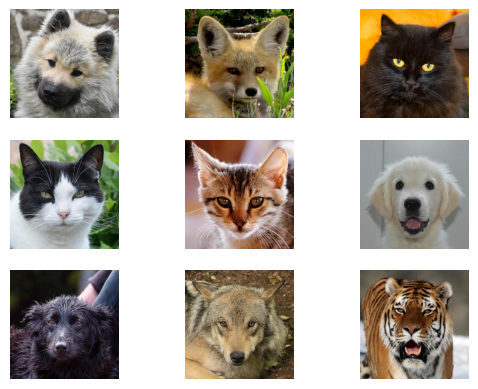

In [13]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_path'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [14]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [15]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle= True)

In [16]:
class Net(nn.Module):
  def __init__(self):
    super().__init__(),
    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64,kernel_size=3,padding=1 )
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3,padding=1)

    self.pooling = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16),128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))
  def forward(self,x):
    x= self.conv1(x)#->(32,128,128)
    x = self.pooling(x)#->(32,64,64)
    x = self.relu(x)

    x= self.conv2(x)#(64,64,64)
    x = self.pooling(x)#->(64,32,32)
    x = self.relu(x)

    x= self.conv3(x)#(128,32,32)
    x = self.pooling(x)#->(128,16,16)
    x = self.relu(x)

    x= self.flatten(x)
    x= self.linear(x)
    x= self.output(x)
    return x


In [17]:
model = Net().to(device)


In [18]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [20]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
  print("="*25)

Epoch 1/10, Train Loss: 3.3069 Train Accuracy 80.728
              Validation Loss: 0.4021 Validation Accuracy: 90.4132
Epoch 2/10, Train Loss: 1.5529 Train Accuracy 92.1885
              Validation Loss: 0.2795 Validation Accuracy: 92.6446
Epoch 3/10, Train Loss: 1.0189 Train Accuracy 94.8012
              Validation Loss: 0.2691 Validation Accuracy: 93.6364
Epoch 4/10, Train Loss: 0.7397 Train Accuracy 96.3422
              Validation Loss: 0.1948 Validation Accuracy: 95.0413
Epoch 5/10, Train Loss: 0.5395 Train Accuracy 97.467
              Validation Loss: 0.169 Validation Accuracy: 95.9917
Epoch 6/10, Train Loss: 0.4278 Train Accuracy 97.9895
              Validation Loss: 0.1705 Validation Accuracy: 96.1157
Epoch 7/10, Train Loss: 0.3008 Train Accuracy 98.5032
              Validation Loss: 0.1998 Validation Accuracy: 95.8264
Epoch 8/10, Train Loss: 0.2164 Train Accuracy 98.9726
              Validation Loss: 0.1537 Validation Accuracy: 96.5289
Epoch 9/10, Train Loss: 0.152 Train

In [21]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs , labels in test_loader:
    predictions = model(inputs)
    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    test_loss = criterion(predictions, labels)
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()
print(f"Accuracy Score is: { round(( total_acc_test/test_dataset.__len__())*100,4)} and loss is{round(total_loss_test/1000 , 4)}")


Accuracy Score is: 96.9409 and loss is0.0164


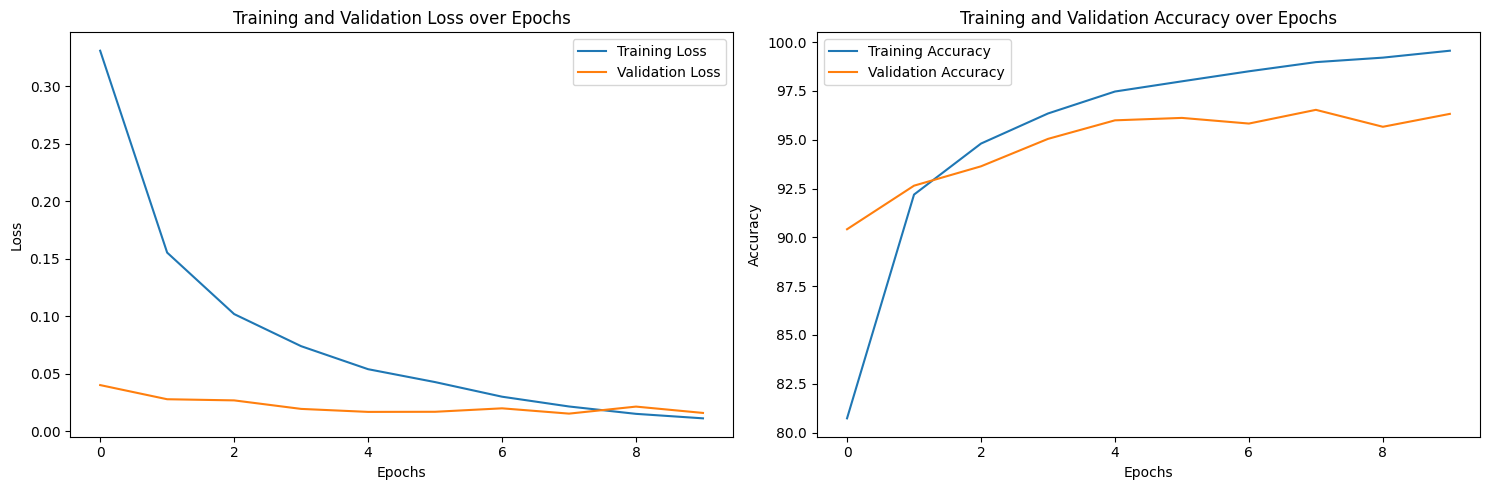

In [22]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

In [23]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])